# Fusion de flux multi-modèle (yeux + tête)

Architecture de stacking à deux flux compatible avec tous les modèles disponibles :
`random_forest` / `xgboost` / `svm` / `cnn_1d` / `inception_time` / `bilstm` / `cnn_lstm`

- **Flux yeux** : un modèle entraîné uniquement sur les features oculaires
- **Flux tête** : un modèle entraîné uniquement sur les features de mouvement de tête
- **Méta-modèle** : reçoit les prédictions des deux flux et produit la prédiction finale

Les modèles de flux sont entraînés sur `train`, leurs prédictions sur `val` alimentent le méta-modèle — pas de fuite de données.

Chaque flux peut utiliser un modèle différent via `STREAM_PROFILES`. Les modèles deep (cnn_1d, etc.) reçoivent X reshapé en `(n_samples, n_stream_features, 1)`.

In [30]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.extract import add_target, load_csv_features
from pipeline.pretraitement import apply_preprocess, apply_target_discretization, prepare_splits_and_impute
from pipeline.visu_pretraitement import plot_feature_report, plot_preprocessing_report, plot_split_report
from pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_pca_if_classification,
)
from pipeline.fusion import (
    build_meta_model,
    make_meta_features,
    split_feature_streams,
    train_stream_models,
)
from pipeline.reporting import export_visual_report

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

Seed globale: 42


## 1) Profils modulaires

In [31]:
DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Indicateurs calculés/FullTimeIndicatorsMinutes1.csv",
    "subject_id_col": "Participant",
    "feature_columns": {
        0: "Time",
        1: "HMDPosX",
        2: "HMDPosY",
        3: "HMDPosZ",
        4: "RotX",
        5: "RotY",
        6: "RotZ",
        7: "SuggestedRotationX",
        8: "SuggestedRotationY",
        9: "SuggestedRotationZ",
        10: "LeftPupilDiameter",
        11: "RightPupilDiameter",
        12: "XGazeDirection",
        13: "YGazeDirection",
        14: "Confidence",
        15: "IsBoat",
        16: "XWorldPosition",
        17: "YWorldPosition",
    },
    "subject_id_count_hint": 42,
}

PREPROCESS_PROFILE = {
    "clip_quantiles": [0.01, 0.99],   # clip sur les features
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": "standard",      # obligatoire pour svm — None | "standard" | "minmax"
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "per_minute",
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "Minute",
    "clip_quantiles": None,
    "discretize": {                   # None pour regression
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium", "high"],
    },
}

MODEL_PROFILE = {
    # Profil de base — task_type et split partagés par tous les flux
    # model_type utilisé uniquement si STREAM_PROFILES est None
    # Choisir parmi : random_forest / xgboost / svm / cnn_1d / inception_time / bilstm / cnn_lstm
    # Note : svm requiert normalization != None dans PREPROCESS_PROFILE
    "model_type": "xgboost",
    "task_type": "classification",   # classification / regression
    "split_method": "group",
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

# Profil par flux — None pour utiliser MODEL_PROFILE sur tous les flux
# Décommenter et ajuster pour utiliser des modèles différents par flux
STREAM_PROFILES = None
# STREAM_PROFILES = {
#     "eye":  {**MODEL_PROFILE, "model_type": "cnn_1d"},
#     "head": {**MODEL_PROFILE, "model_type": "random_forest"},
# }

# Noms de colonnes exacts du CSV — verifier avec la cellule 5.quat si une colonne est introuvable
# Minute/minute apparaissent dans les deux flux (contexte temporel commun)
FUSION_PROFILE = {
    "streams": {
        "eye": [
            "%Pow01EyeX",    # % puissance spectrale regard horizontal (bande 0.1 Hz)
            "%Pow01EyeY",    # % puissance spectrale regard vertical   (bande 0.1 Hz)
            "%Pow04EyeX",    # % puissance spectrale regard horizontal (bande 0.4 Hz)
            "%Pow04EyeY",    # % puissance spectrale regard vertical   (bande 0.4 Hz)
            "Ellipse95Eye",  # surface ellipse 95% du mouvement oculaire
            "PupilDiamX",    # diametre pupille axe X
            "PupilDiamY",    # diametre pupille axe Y
            "Amp01EyeX",     # amplitude mouvement oculaire X (bande 0.1 Hz)
            "Amp01EyeY",     # amplitude mouvement oculaire Y (bande 0.1 Hz)
            "Amp04EyeX",     # amplitude mouvement oculaire X (bande 0.4 Hz)
            "Amp04EyeY",     # amplitude mouvement oculaire Y (bande 0.4 Hz)
            "TotMovEyeX",    # mouvement total oculaire axe X
            "TotMovEyeY",    # mouvement total oculaire axe Y
            "Minute",        # indice temporel (contexte commun)
            "minute",        # idem, variante minuscule selon la source
        ],
        "head": [
            "Amp01X",            # amplitude mouvement tete X (bande 0.1 Hz)
            "Amp01Y",            # amplitude mouvement tete Y (bande 0.1 Hz)
            "Amp01Z",            # amplitude mouvement tete Z (bande 0.1 Hz)
            "Amp04X",            # amplitude mouvement tete X (bande 0.4 Hz)
            "Amp04Y",            # amplitude mouvement tete Y (bande 0.4 Hz)
            "Amp04Z",            # amplitude mouvement tete Z (bande 0.4 Hz)
            "TotMovX",           # mouvement total tete axe X
            "TotMovY",           # mouvement total tete axe Y
            "TotMovZ",           # mouvement total tete axe Z
            "TotMovXYZ",         # mouvement total tete norme 3D
            "%Pow01X",           # % puissance spectrale tete X (bande 0.1 Hz)
            "%Pow01Y",           # % puissance spectrale tete Y (bande 0.1 Hz)
            "%Pow01Z",           # % puissance spectrale tete Z (bande 0.1 Hz)
            "%Pow04X",           # % puissance spectrale tete X (bande 0.4 Hz)
            "%Pow04Y",           # % puissance spectrale tete Y (bande 0.4 Hz)
            "%Pow04Z",           # % puissance spectrale tete Z (bande 0.4 Hz)
            "Ellipse95WorldPos", # surface ellipse 95% de la position monde
            "%Boat",             # % du temps en situation de bateau
            "Minute",            # indice temporel (contexte commun)
            "minute",            # idem, variante minuscule selon la source
        ],
    },
    # Modèle de la dernière couche (independant du model_type des flux)
    # Choisir parmi : logistic_regression / random_forest / svm / xgboost
    "meta_model": "logistic_regression",
}

EVAL_PROFILE = {
    "robustness_noise_std": 0.01,
    "robustness_repeats": 5,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/fusion_modulaire",
    "save_visual_report": True,
    "visual_report_format": "both",  # pdf / png / both
    "visual_report_name": "visual_report_fusion",
    # "all" pour tout, ou une liste explicite de fonctions
    "visual_report_functions": [
        "visual_hypothesis_page",
        "visual_cover_page",
        "visual_model_architecture_page",
        "visual_split_report",
        "visual_metrics_table_page",
        "visual_confusion_matrix_page",
        "visual_missing_values_bar",
        "visual_correlation_pages",
        "visual_violin_pages",
    ],
    "max_corr_features": 24,
    "max_violin_features": 48,
    "violin_features_per_page": 6,
    # Texte libre presente sur la page de garde du rapport visuel (optionnel)
    "hypothesis": (
        """
            hypothese : la fusion de flux oculaires et cephaliques
            ameliore la prediction du malaise cybersickness
        """
    ),
}

_active_profiles = STREAM_PROFILES if STREAM_PROFILES is not None else MODEL_PROFILE
_model_type_display = (
    {k: v["model_type"] for k, v in STREAM_PROFILES.items()}
    if STREAM_PROFILES is not None
    else MODEL_PROFILE["model_type"]
)
print("Profils charges")
print("Modèle flux    :", _model_type_display)
print("Tache          :", MODEL_PROFILE["task_type"])
print("Méta-modèle    :", FUSION_PROFILE["meta_model"])
print("Normalisation  :", PREPROCESS_PROFILE.get("normalization") or "aucune")
print("Modèles dispo  :", "random_forest / xgboost / svm / cnn_1d / inception_time / bilstm / cnn_lstm")

Profils charges
Modèle flux    : xgboost
Tache          : classification
Méta-modèle    : logistic_regression
Normalisation  : standard
Modèles dispo  : random_forest / xgboost / svm / cnn_1d / inception_time / bilstm / cnn_lstm


## 3) Chargement des données

In [32]:
if DATA_PROFILE["source"] == "csv":
    features_df = load_csv_features(DATA_PROFILE)
    print("Source CSV detectee: les features sont chargees telles quelles.")

elif DATA_PROFILE["source"] == "mat":
    raise NotImplementedError(
        "Le chemin MAT doit maintenant etre orchestre via des fonctions dediees dans pipeline si necessaire."
    )

else:
    raise ValueError("DATA_PROFILE['source'] doit etre 'csv' ou 'mat'.")

print("Shape:", features_df.shape)
display(features_df.head())


Source CSV detectee: les features sont chargees telles quelles.
Shape: (588, 34)


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow01EyeX,%Pow01EyeY,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id
0,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0933,1,0.138978,0.095120,0.016308,0.084265,0.100830,0.173925,2166.960484,9533.470190,...,2.561688,4.804704,0.038757,4.804704,0.123952,319.224603,3.333145,3.465322,1.587302,1
2,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,2.062268,0.908652,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,2
3,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,1.433131,8.315259,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,4


## 4) Integration de la cible

In [33]:
dataset_df = add_target(features_df, TARGET_PROFILE)
print("Dataset avec cible:", dataset_df.shape)
display(dataset_df.head())

Dataset avec cible: (522, 36)


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id,minute,target
0,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,2,1,7.0
1,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,4.0
2,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,4,1,8.0
3,am3001,1,0.063596,0.014971,0.032345,0.095778,0.044423,0.032648,1922.915362,793.806587,...,0.215129,8.185577,0.103624,157.331180,5.250478,5.144878,0.751880,5,1,3.0
4,AP1133,1,0.009319,0.003780,0.003951,0.003373,0.033734,0.053038,108.184186,114.219420,...,1.963714,31.873764,0.034554,41.801993,3.533532,3.688725,0.000000,6,1,4.0


## 5) Pretraitement, split et preparation

In [34]:
def display_target_info(df, model_profile, target_profile=None, preprocess_profile=None):
    task = model_profile.get("task_type", "regression")
    target = df["target"]
    if task == "classification":
        print("Classes:", sorted(target.dropna().unique().tolist()))
        print("Distribution:")
        print(target.value_counts().sort_index())
    else:
        print("Distribution cible (regression):")
        print(target.describe())
    if target_profile and target_profile.get("clip_quantiles"):
        q_low, q_high = target_profile["clip_quantiles"]
        print(f"\nClip quantiles cible   : [{q_low}, {q_high}]")
    if preprocess_profile and preprocess_profile.get("clip_quantiles"):
        q_low, q_high = preprocess_profile["clip_quantiles"]
        print(f"Clip quantiles features: [{q_low}, {q_high}]")


dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)
display_target_info(dataset_df, MODEL_PROFILE, TARGET_PROFILE, PREPROCESS_PROFILE)

raw_df = dataset_df.copy()
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp   = prepared["X_val_imp"]
X_test_imp  = prepared["X_test_imp"]
y_train     = prepared["y_train"]
y_val       = prepared["y_val"]
y_test      = prepared["y_test"]
train_idx   = prepared["train_idx"]
val_idx     = prepared["val_idx"]
test_idx    = prepared["test_idx"]
imputer     = prepared["imputer"]
scaler      = prepared["scaler"]

print("\nDataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)


Classes: ['high', 'low', 'medium']
Distribution:
target
low       318
medium    153
high       51
Name: count, dtype: int64
Clip quantiles features: [0.01, 0.99]

Dataset final: (522, 36)
Nombre de features: 31
Split sizes -> train/val/test: 298 112 112
Normalisation appliquee: StandardScaler


## 5.bis) Visualisation du pretraitement

Shape avant prétraitement : (522, 36)
Shape après prétraitement : (522, 36)
Nombre de sujets exclus : 0
Nombre de features droppées (zero-variance) : 2
Nombre total de NaN avant imputation : 731
Seuils de clipping utilisés : [0.01, 0.99]


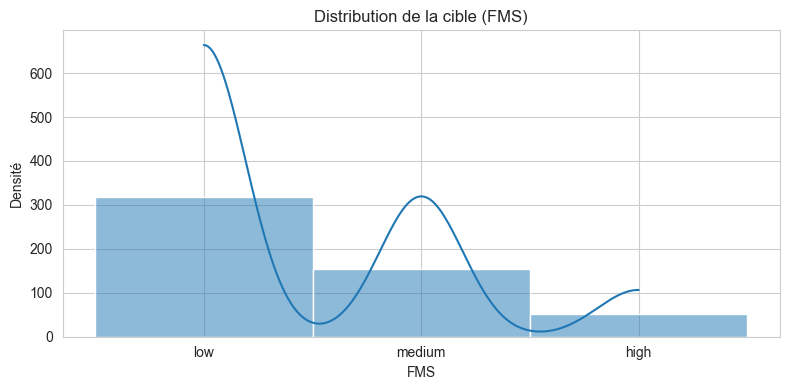

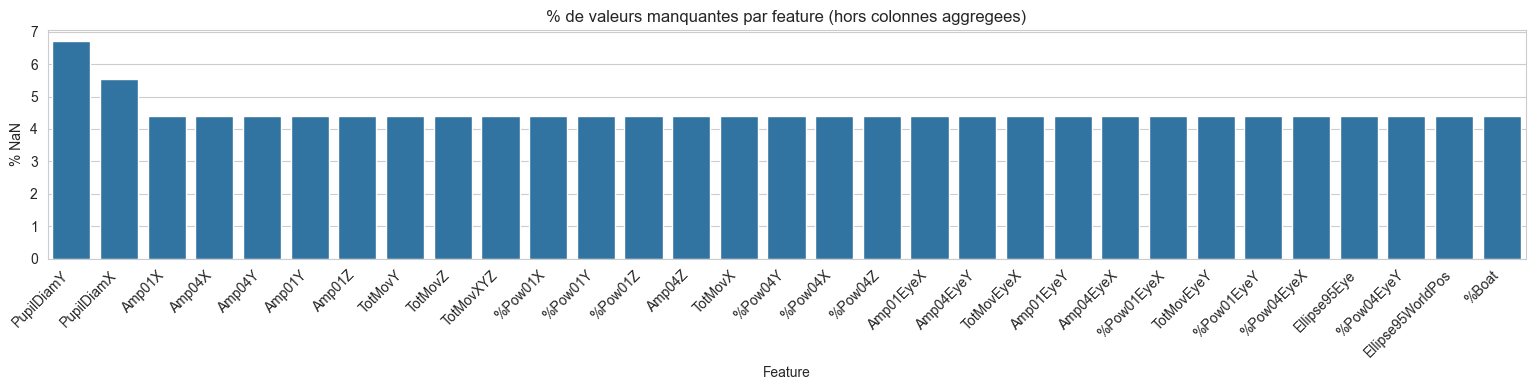

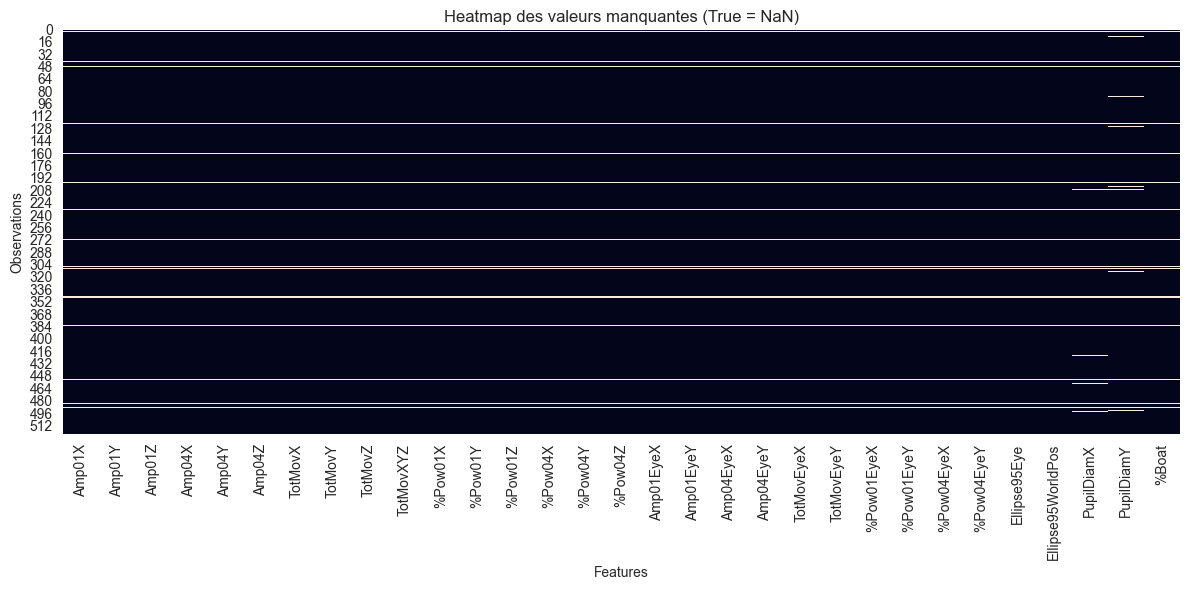

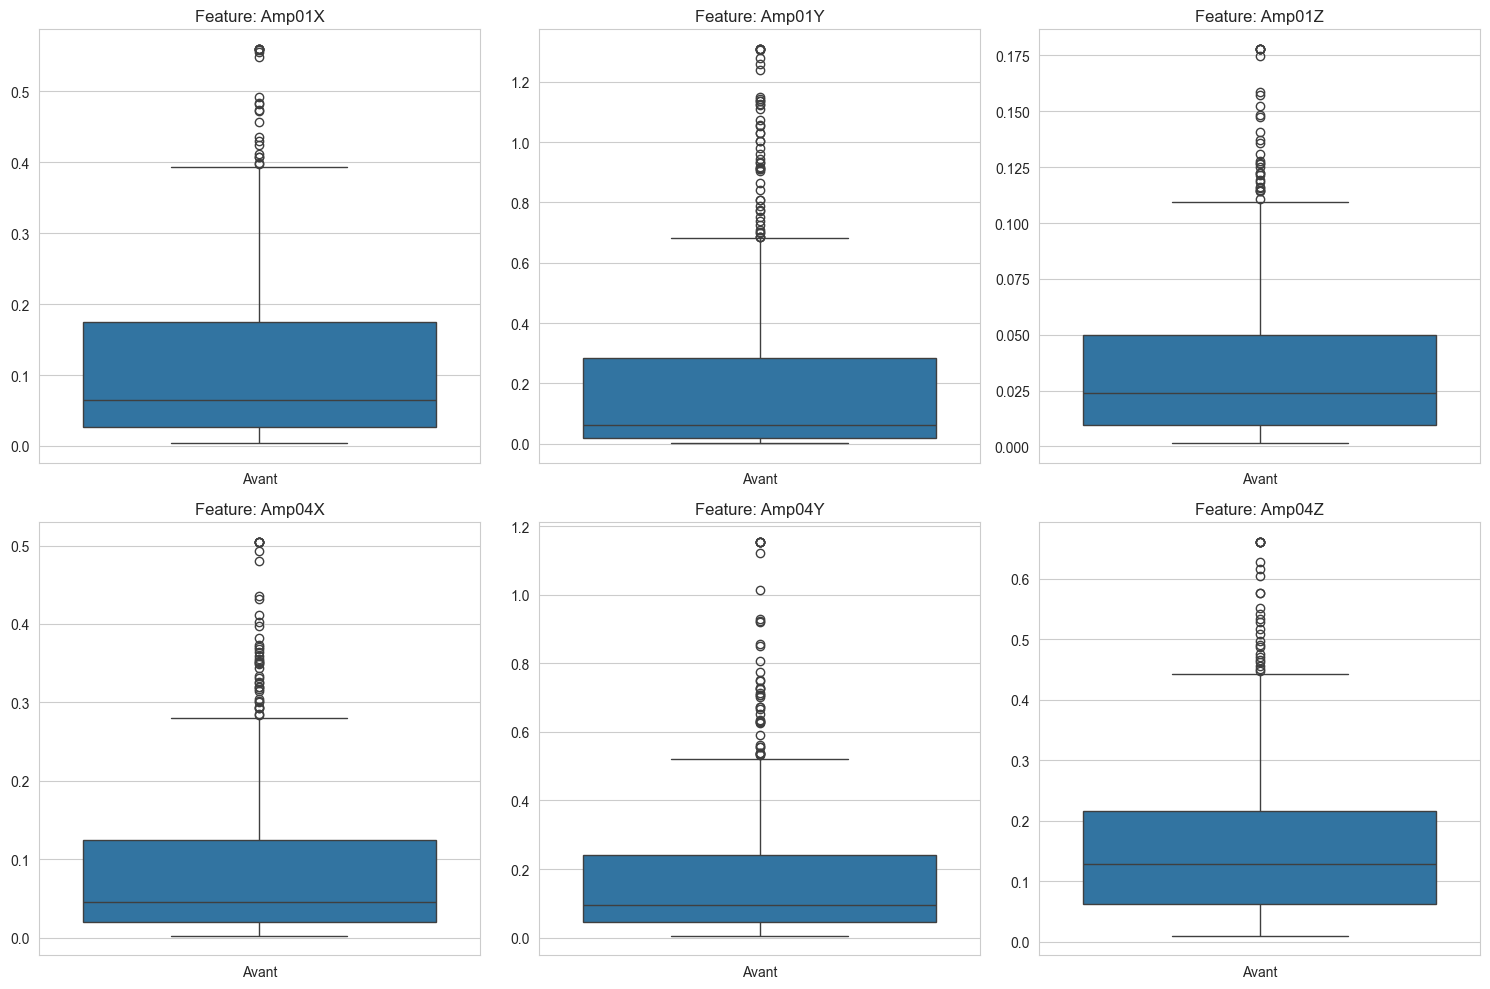

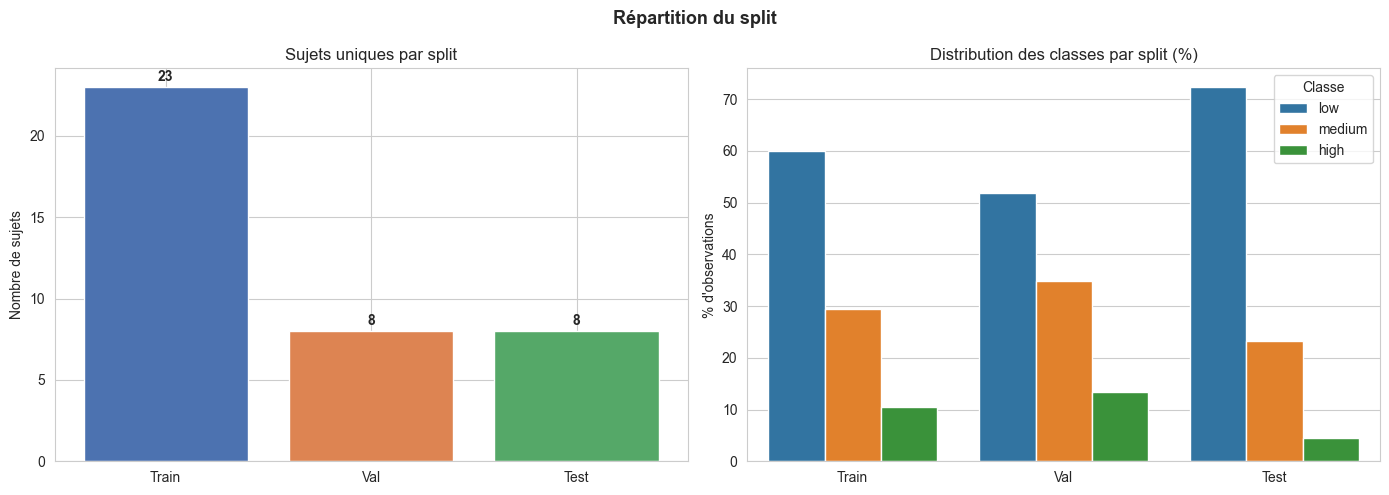

In [35]:
plot_preprocessing_report(raw_df, dataset_df, feature_cols, PREPROCESS_PROFILE)
plot_split_report(dataset_df, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

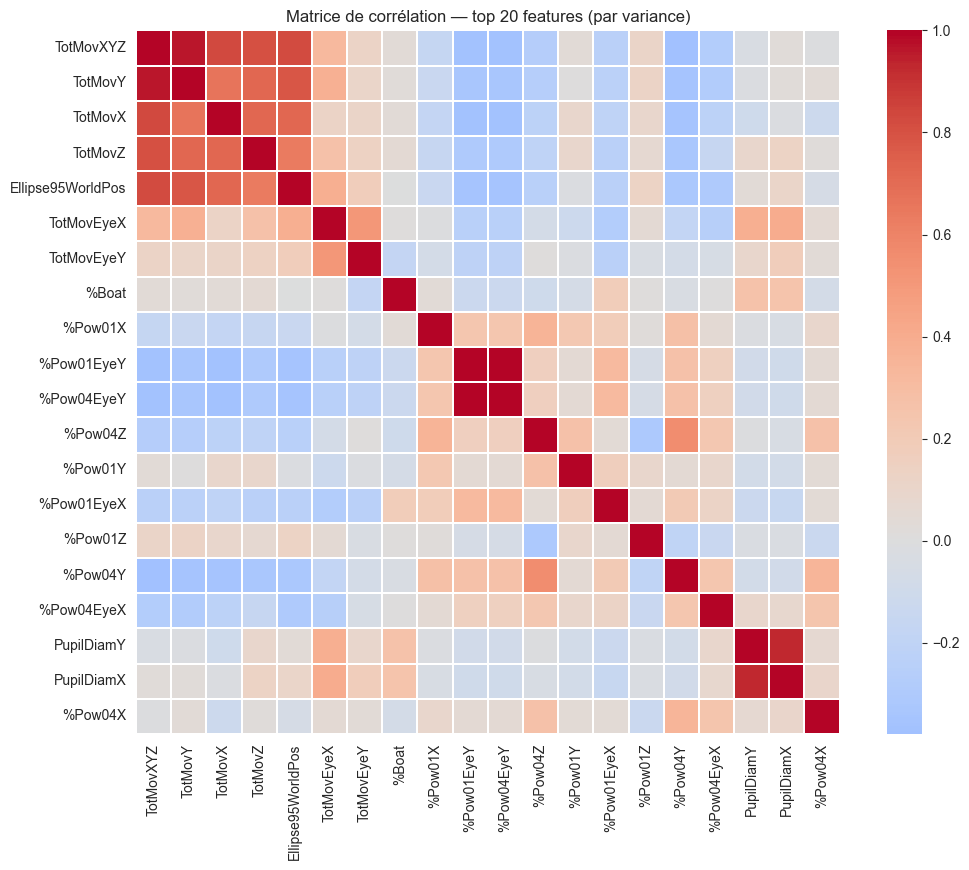

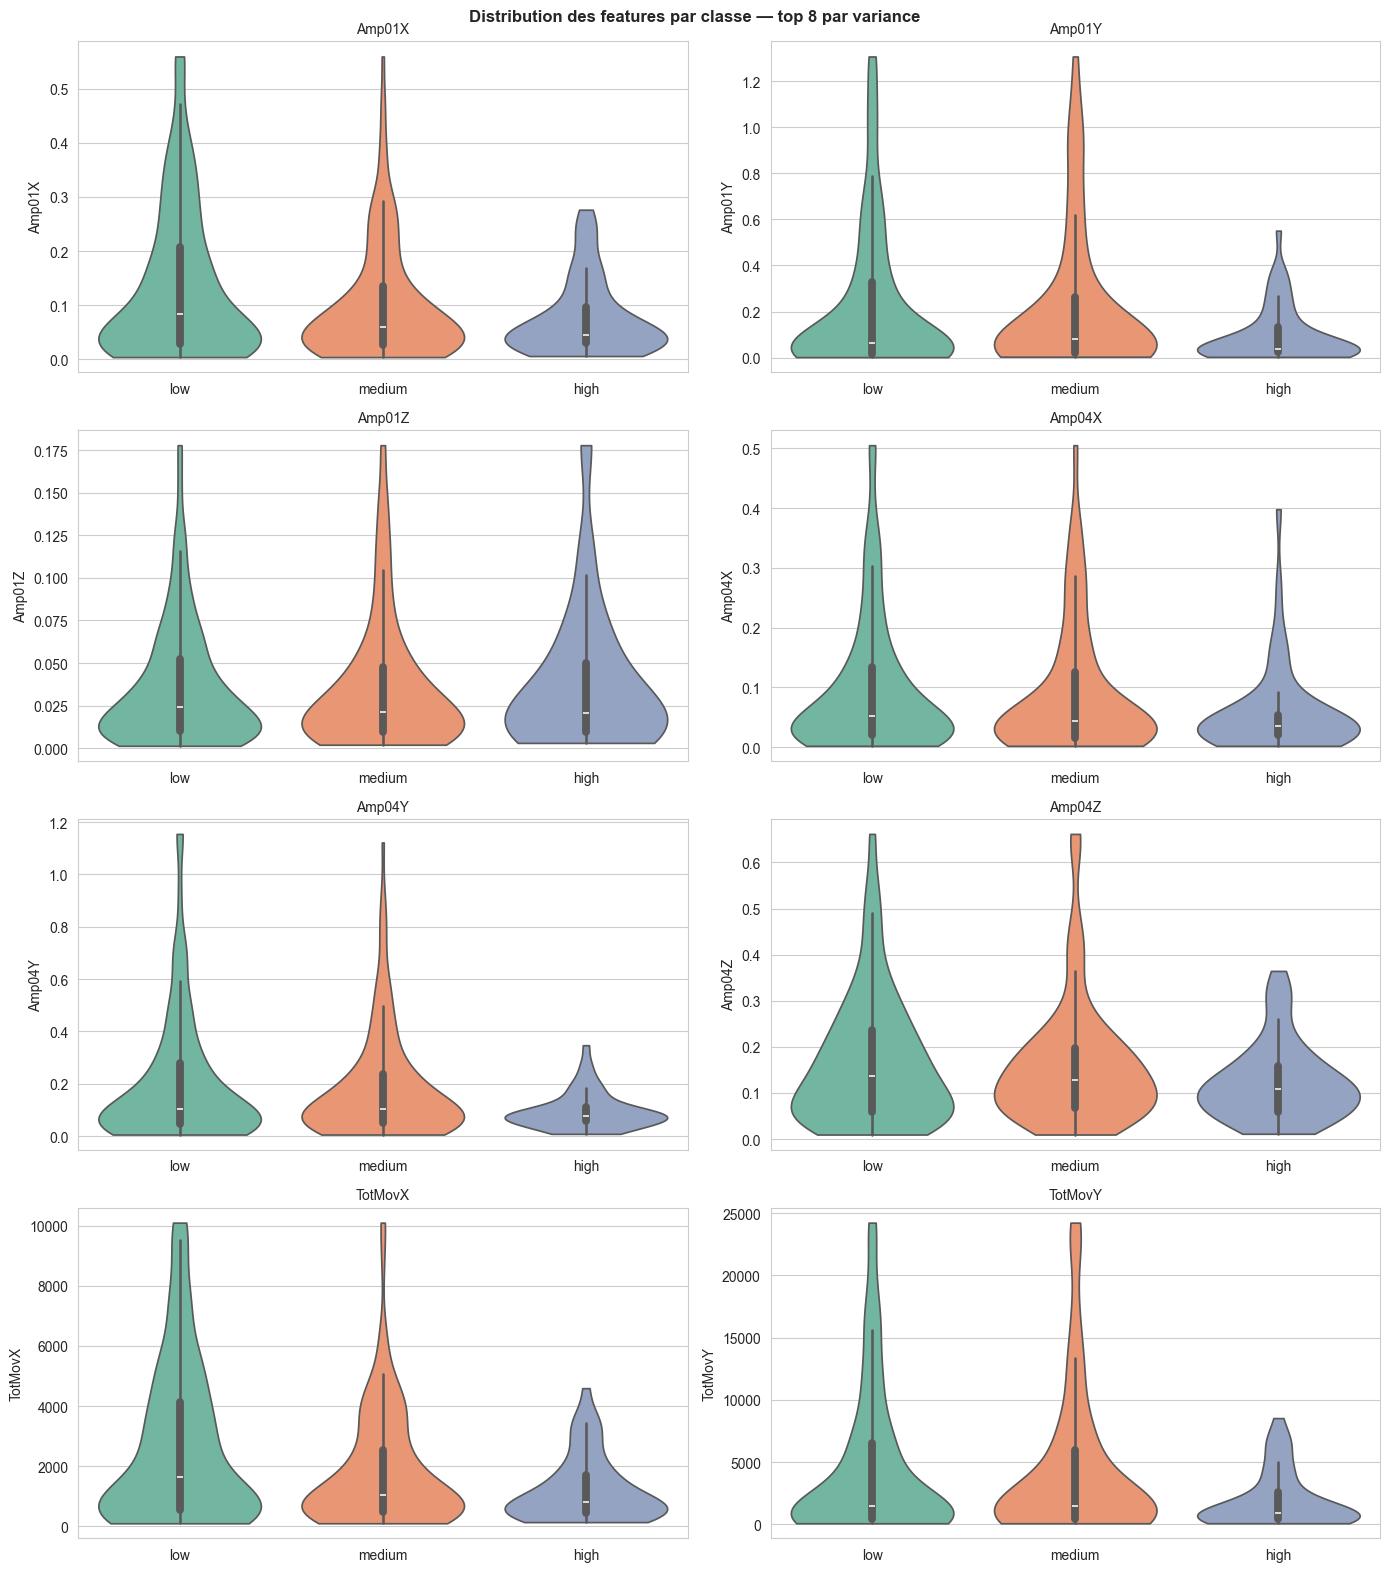

In [36]:
plot_feature_report(dataset_df, feature_cols, MODEL_PROFILE, target_profile=TARGET_PROFILE)

## 5.quat) Répartition des features par flux

In [37]:
stream_map = split_feature_streams(feature_cols, FUSION_PROFILE)

for stream_name, cols in stream_map.items():
    print(f"\n--- Flux '{stream_name}' ({len(cols)} features) ---")
    print(cols)

total_assigned = sum(len(v) for v in stream_map.values())
print(f"\nTotal features assignées : {total_assigned} / {len(feature_cols)}")

[fusion] Avertissement : 'Minute' introuvable dans feature_cols (flux 'eye').
[fusion] Avertissement : 'minute' introuvable dans feature_cols (flux 'eye').
[fusion] Avertissement : 'Minute' introuvable dans feature_cols (flux 'head').
[fusion] Avertissement : 'minute' introuvable dans feature_cols (flux 'head').

--- Flux 'eye' (13 features) ---
['%Pow01EyeX', '%Pow01EyeY', '%Pow04EyeX', '%Pow04EyeY', 'Ellipse95Eye', 'PupilDiamX', 'PupilDiamY', 'Amp01EyeX', 'Amp01EyeY', 'Amp04EyeX', 'Amp04EyeY', 'TotMovEyeX', 'TotMovEyeY']

--- Flux 'head' (18 features) ---
['Amp01X', 'Amp01Y', 'Amp01Z', 'Amp04X', 'Amp04Y', 'Amp04Z', 'TotMovX', 'TotMovY', 'TotMovZ', 'TotMovXYZ', '%Pow01X', '%Pow01Y', '%Pow01Z', '%Pow04X', '%Pow04Y', '%Pow04Z', 'Ellipse95WorldPos', '%Boat']

Total features assignées : 31 / 31


## 6) Entraînement des modèles de flux et du méta-modèle

**Protocole sans fuite :**
1. Modèles de flux entraînés sur `train`
2. Prédictions sur `val` → méta-features d'entraînement du méta-modèle
3. Évaluation finale sur `test` (jamais vu par aucun modèle)

In [38]:
print("=== Entraînement des modèles de flux ===")
stream_models = train_stream_models(
    X_train=X_train_imp,
    y_train=y_train,
    X_val=X_val_imp,
    y_val=y_val,
    stream_map=stream_map,
    feature_cols=feature_cols,
    model_profile=STREAM_PROFILES if STREAM_PROFILES is not None else MODEL_PROFILE,
)

is_classif = MODEL_PROFILE["task_type"] == "classification"

print("\n=== Construction des méta-features ===")
meta_X_train = make_meta_features(stream_models, stream_map, X_train_imp, feature_cols, is_classif)
meta_X_val   = make_meta_features(stream_models, stream_map, X_val_imp,   feature_cols, is_classif)
meta_X_test  = make_meta_features(stream_models, stream_map, X_test_imp,  feature_cols, is_classif)
print(f"Shape méta-features train : {meta_X_train.shape}")
print(f"Shape méta-features val   : {meta_X_val.shape}")
print(f"Shape méta-features test  : {meta_X_test.shape}")

print("\n=== Entraînement du méta-modèle ===")
meta_model = build_meta_model(FUSION_PROFILE, MODEL_PROFILE["task_type"], seed=SEED)
# Le méta-modèle s'entraîne sur train + val pour maximiser les données disponibles
meta_model.fit(
    np.vstack([meta_X_train, meta_X_val]),
    np.concatenate([y_train, y_val]),
)
print("Méta-modèle:", type(meta_model).__name__)

=== Entraînement des modèles de flux ===
[fusion] Stream 'eye' (13 features, xgboost) -> F1 val: 0.3927
[fusion] Stream 'head' (18 features, xgboost) -> F1 val: 0.3929

=== Construction des méta-features ===
Shape méta-features train : (298, 6)
Shape méta-features val   : (112, 6)
Shape méta-features test  : (112, 6)

=== Entraînement du méta-modèle ===
Méta-modèle: LogisticRegression


## 7) Evaluation, robustesse et visualisations

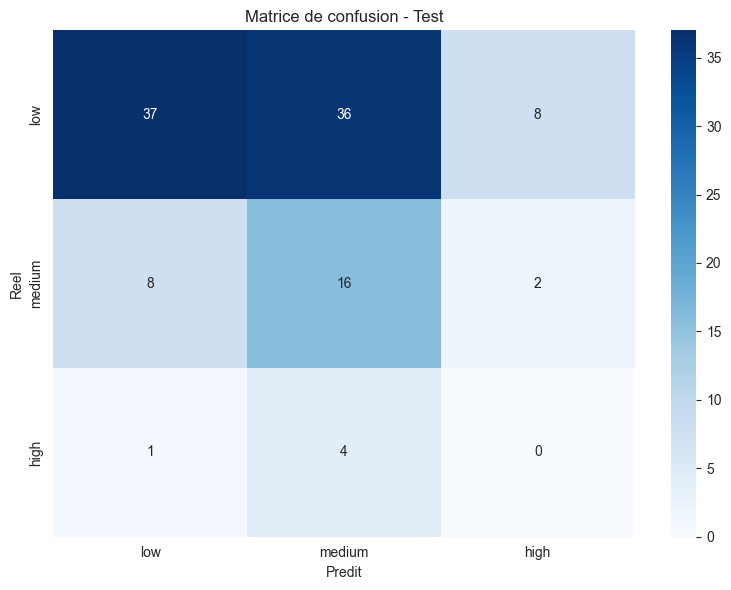

accuracy              0.473214
precision_weighted    0.648042
recall_weighted       0.473214
f1_weighted           0.511993
dtype: float64

Classification report:
              precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.80      0.46      0.58        81
      medium       0.29      0.62      0.39        26

    accuracy                           0.47       112
   macro avg       0.36      0.36      0.32       112
weighted avg       0.65      0.47      0.51       112



,subject_id,n,accuracy,f1_weighted
0,BM1997,14.0,0.642857,0.625668
1,CH1308,14.0,0.142857,0.250000
2,FC1997,14.0,0.214286,0.352941
3,NB1934,14.0,0.642857,0.782609
4,NT1234,14.0,0.500000,0.577068
5,RU3300,14.0,0.571429,0.539889
6,ab0710,14.0,0.500000,0.547619
7,rl2704,14.0,0.571429,0.707483


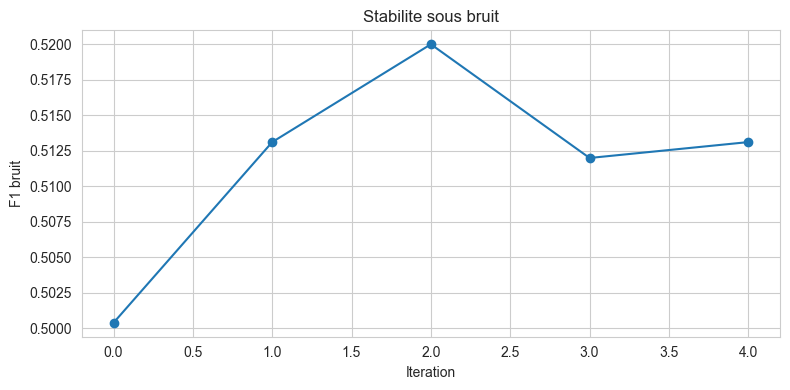

Score robustesse (moyenne): 0.511720551531951


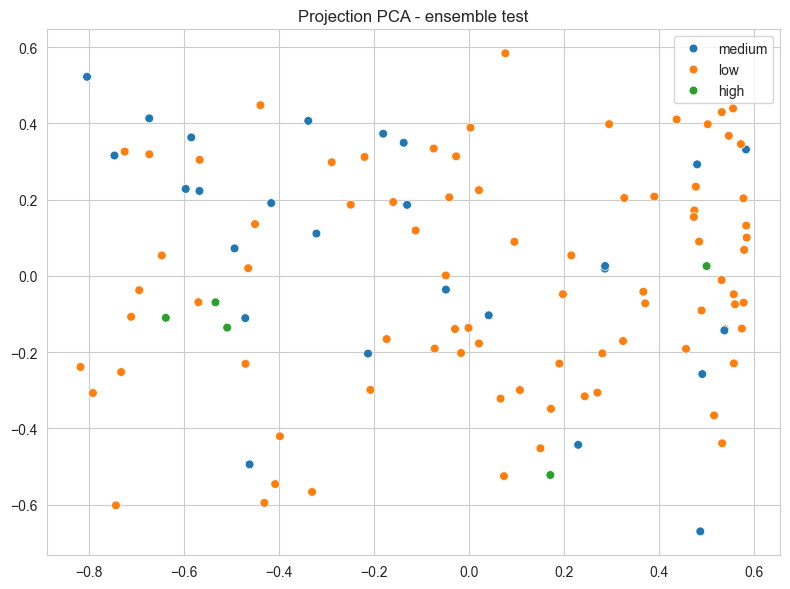

In [39]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=meta_model,
    X_test_imp=meta_X_test,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    target_profile=TARGET_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))

noise_scores = evaluate_robustness(
    final_model=meta_model,
    X_test_imp=meta_X_test,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    eval_profile=EVAL_PROFILE,
    seed=SEED,
    show_plot=True,
)
print("Score robustesse (moyenne):", float(np.mean(noise_scores)))

plot_pca_if_classification(meta_X_test, y_test, MODEL_PROFILE, seed=SEED)

### 7.bis) Performance individuelle par flux

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

print("Performance individuelle de chaque flux sur le test set:\n")
for stream_name, stream_model in stream_models.items():
    from pipeline.fusion import _col_indices
    idx = _col_indices(stream_map[stream_name], feature_cols)
    X_s = X_test_imp[:, idx]
    if hasattr(stream_model, "input_shape"):
        X_s = X_s.reshape(-1, X_s.shape[1], 1)
    pred_s = stream_model.predict(X_s)

    if is_classif:
        acc = accuracy_score(y_test, pred_s)
        f1  = f1_score(y_test, pred_s, average="weighted", zero_division=0)
        print(f"  [{stream_name}]  accuracy={acc:.3f}  F1={f1:.3f}")
    else:
        mae  = mean_absolute_error(y_test, pred_s)
        rmse = float(np.sqrt(np.mean((y_test - pred_s) ** 2)))
        print(f"  [{stream_name}]  MAE={mae:.3f}  RMSE={rmse:.3f}")

print()
if is_classif:
    print(f"  [fusion]  accuracy={metrics['accuracy']:.3f}  F1={metrics['f1_weighted']:.3f}")
else:
    print(f"  [fusion]  MAE={metrics['mae']:.3f}  RMSE={metrics['rmse']:.3f}")

## 8) Fiche modele

In [41]:
import joblib
out_dir = OUTPUT_PROFILE["output_dir"]
os.makedirs(out_dir, exist_ok=True)

joblib.dump(meta_model, os.path.join(out_dir, "meta_model.joblib"))
for name, m in stream_models.items():
    joblib.dump(m, os.path.join(out_dir, f"stream_{name}.joblib"))
if imputer is not None:
    joblib.dump(imputer, os.path.join(out_dir, "imputer.joblib"))
if scaler is not None:
    joblib.dump(scaler, os.path.join(out_dir, "scaler.joblib"))

print("Modeles sauvegardes:")
print("- meta_model.joblib")
for name in stream_models:
    print(f"- stream_{name}.joblib")

export_visual_report(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    output_profile=OUTPUT_PROFILE,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    target_profile=TARGET_PROFILE,
    raw_df=raw_df,
    preprocess_profile=PREPROCESS_PROFILE,
    metrics=metrics,
    final_model=meta_model,
    X_test_imp=meta_X_test,
    y_test=y_test,
)

Modeles sauvegardes:
- meta_model.joblib
- stream_eye.joblib
- stream_head.joblib


{'pages': 15,
 'report_name': 'visual_report_fusion_20260528_100618',
 'pdf_path': '../data/outputs/fusion_modulaire\\visual_report_fusion_20260528_100618.pdf',
 'png_dir': '../data/outputs/fusion_modulaire\\visual_report_fusion_20260528_100618_png'}